# 01 — Data Loader & Returns

This notebook demonstrates Module 1:
- Download OHLCV data via `quantlab.data.loader`
- Compute daily/log/cumulative returns
- Print a performance summary table
- Compare against SPY benchmark

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from quantlab.data.loader import load_ohlcv
from quantlab.features.returns import (
    calculate_returns,
    calculate_cumulative_returns,
)
from quantlab.evaluation.metrics import performance_summary

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True

## 1. Download data

In [2]:
SYMBOLS  = ['AAPL', 'MSFT', 'NVDA', 'SPY']
START    = '2020-01-01'
END      = '2026-05-01'

# Resolve project root regardless of where Jupyter was launched from
import os
from pathlib import Path
_cwd = Path(os.getcwd()).resolve()
PROJECT_ROOT = _cwd.parent if _cwd.name == 'notebooks' else _cwd
CACHE = str(PROJECT_ROOT / "data" / "cache")

data = load_ohlcv(SYMBOLS, start_date=START, end_date=END, cache_dir=CACHE)
print(data.shape)
data.head(8)

2026-05-24 23:42:23,531 [INFO] quantlab.data.loader: Cache hit: AAPL
2026-05-24 23:42:29,205 [INFO] quantlab.data.loader: Cache hit: MSFT
2026-05-24 23:42:29,207 [INFO] quantlab.data.loader: Cache hit: NVDA
2026-05-24 23:42:29,210 [INFO] quantlab.data.loader: Cache hit: SPY
(5032, 5)


Price                    open        high         low       close     volume
date       symbol                                                           
2020-01-02 AAPL     71.344054   72.394086   71.091184   72.333878  135480400
           MSFT    150.090263  151.933540  149.664893  151.829559   22622100
           NVDA      5.941885    5.970755    5.891364    5.970755  237536000
           SPY     295.672752  296.906479  294.749737  296.888184   59151200
2020-01-03 AAPL     71.563190   72.389242   71.406651   71.630623  146322800
           MSFT    149.655441  151.196224  149.409661  149.939011   21116200
           NVDA      5.851046    5.918989    5.826158    5.875186  205384000
           SPY     293.497711  295.764112  293.442881  294.640045   77709700

## 2. Compute returns per symbol

In [3]:
returns = (
    data['close']
    .unstack('symbol')
    .apply(calculate_returns)
)
returns.head()

symbol,AAPL,MSFT,NVDA,SPY
date,,,,
2020-01-02,NaN,NaN,NaN,NaN
2020-01-03,-0.009722,-0.012452,-0.016006,-0.007572
2020-01-06,0.007969,0.002585,0.004194,0.003815
2020-01-07,-0.004703,-0.009118,0.012107,-0.002812
2020-01-08,0.016087,0.015928,0.001875,0.005329


## 3. Plot cumulative returns

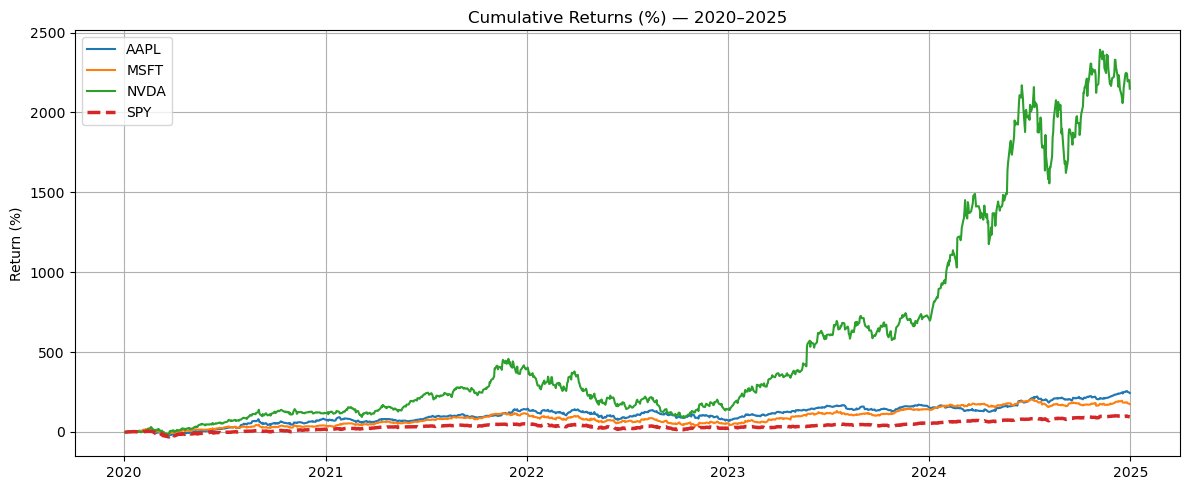

In [4]:
cum_returns = returns.apply(calculate_cumulative_returns)

fig, ax = plt.subplots()
for col in cum_returns.columns:
    lw = 2.5 if col == 'SPY' else 1.5
    ls = '--' if col == 'SPY' else '-'
    ax.plot(cum_returns.index, cum_returns[col] * 100, label=col, linewidth=lw, linestyle=ls)

ax.set_title('Cumulative Returns (%) — 2020–2025')
ax.set_ylabel('Return (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/cumulative_returns.png', dpi=150)
plt.show()

## 4. Performance summary table

In [5]:
spy_returns = returns['SPY'].dropna()

rows = []
for symbol in [s for s in SYMBOLS if s != 'SPY']:
    r = returns[symbol].dropna()
    summary = performance_summary(r, benchmark_returns=spy_returns)
    summary['symbol'] = symbol
    rows.append(summary)

summary_df = pd.DataFrame(rows).set_index('symbol')
fmt = {
    'total_return': '{:.1%}',
    'annualized_return': '{:.1%}',
    'annualized_volatility': '{:.1%}',
    'sharpe_ratio': '{:.2f}',
    'max_drawdown': '{:.1%}',
    'alpha_annualized': '{:.1%}',
    'beta': '{:.2f}',
    'information_ratio': '{:.2f}',
}
summary_df.style.format(fmt)

,total_return,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,n_days,alpha_annualized,beta,information_ratio
symbol,,,,,,,,,
AAPL,244.0%,28.1%,31.7%,0.94,-31.4%,1257,13.1%,1.19,0.72
MSFT,174.4%,22.4%,30.5%,0.82,-37.1%,1257,8.0%,1.19,0.52
NVDA,2148.4%,86.6%,53.9%,1.43,-66.3%,1257,69.1%,1.79,1.46


## 5. Next steps

- `02_features_and_factors.ipynb` — build technical factors on this data
- `03_backtest_basic.ipynb` — simple moving-average strategy backtest